In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from astropy.stats import SigmaClip
from astropy.convolution import convolve
from astropy.visualization import ImageNormalize, AsinhStretch, PercentileInterval

from photutils.background import Background2D, MedianBackground
from photutils.segmentation import (
    detect_sources,
    deblend_sources,
    SourceCatalog,
    make_2dgaussian_kernel,
)


# Input and output paths
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PNG_FILE = PROJECT_ROOT / "10.png"
RESULTS_DIR = PROJECT_ROOT / "notebooks" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


# Analysis parameters
BACKGROUND_BOX = 128
DETECTION_SIGMA = 10.0
MIN_PIXELS = 20
SMOOTH_FWHM = 3.0
DEBLEND_LEVELS = 32
DEBLEND_CONTRAST = 0.02

In [2]:
# Load the PNG image

png = Image.open(PNG_FILE).convert("RGBA")
rgba = np.asarray(png, dtype=float)

rgb = rgba[..., :3]
alpha = rgba[..., 3]


# Convert RGB to grayscale intensity

image = (
    0.2126 * rgb[..., 0]
    + 0.7152 * rgb[..., 1]
    + 0.0722 * rgb[..., 2]
)

# Normalize intensity to 0-1

image /= 255.0


# Mask transparent pixels

mask = alpha == 0


print("Image shape:", image.shape)
print("Intensity range:", image.min(), image.max())
print(f"Valid pixels: {(~mask).mean() * 100:.1f}%")

Image shape: (3132, 5543)
Intensity range: 0.015425098039215686 0.9999999999999999
Valid pixels: 100.0%


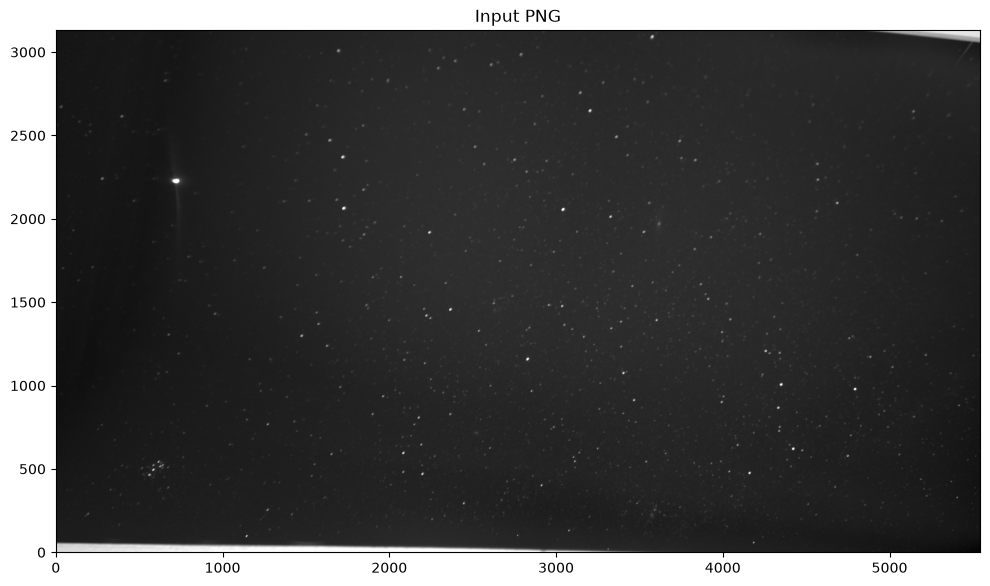

In [3]:
plt.figure(figsize=(10, 10))

plt.imshow(
    image,
    origin="lower",
    cmap="gray",
)

plt.title("Input PNG")
plt.tight_layout()
plt.show()

Median background: 0.15665333333333334
Median background RMS: 0.005108493149917056


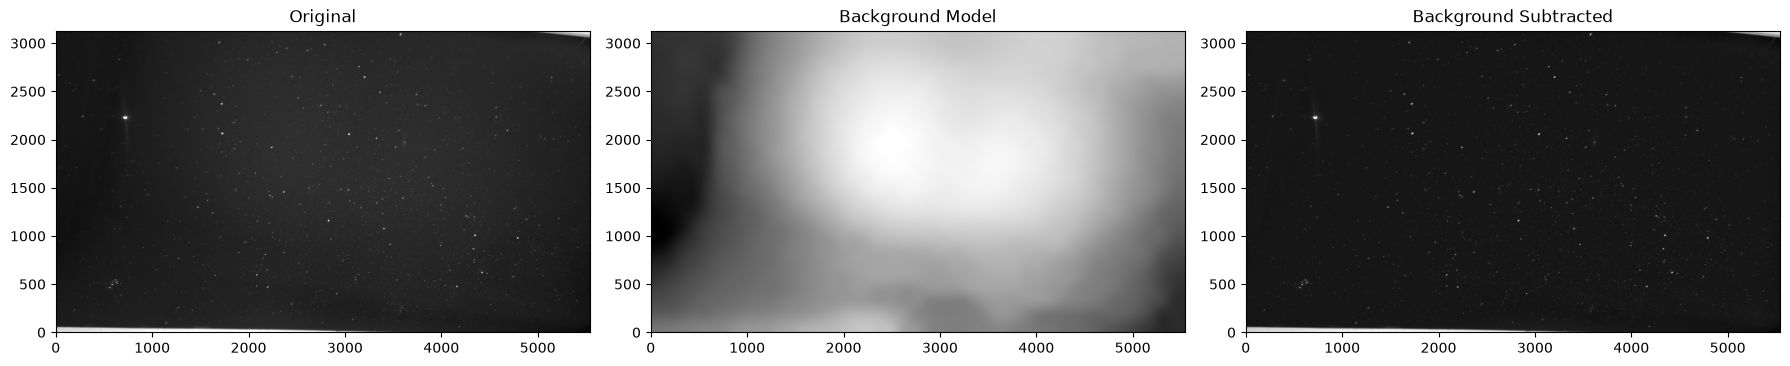

In [4]:
# Estimate the spatially varying image background

sigma_clip = SigmaClip(
    sigma=3.0,
    maxiters=10,
)

background = Background2D(
    image,
    box_size=(BACKGROUND_BOX, BACKGROUND_BOX),
    filter_size=(3, 3),
    mask=mask,
    sigma_clip=sigma_clip,
    bkg_estimator=MedianBackground(),
)


# Subtract the estimated background

data_sub = image - background.background


print("Median background:", background.background_median)
print("Median background RMS:", background.background_rms_median)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image, origin="lower", cmap="gray")
axes[0].set_title("Original")

axes[1].imshow(
    background.background,
    origin="lower",
    cmap="gray",
)
axes[1].set_title("Background Model")

axes[2].imshow(
    data_sub,
    origin="lower",
    cmap="gray",
)
axes[2].set_title("Background Subtracted")

plt.tight_layout()
plt.show()

In [5]:
# Smooth the image for source detection

kernel = make_2dgaussian_kernel(
    fwhm=SMOOTH_FWHM,
    size=5,
)

convolved = convolve(
    data_sub,
    kernel,
    mask=mask,
)


# Build a spatially varying detection threshold

threshold = DETECTION_SIGMA * background.background_rms


# Detect connected source regions

segmentation = detect_sources(
    convolved,
    threshold,
    npixels=MIN_PIXELS,
    mask=mask,
)

if segmentation is None:
    raise RuntimeError(
        "No sources were detected. Try lowering DETECTION_SIGMA."
    )

print("Detected segments:", segmentation.n_labels)

Detected segments: 1060


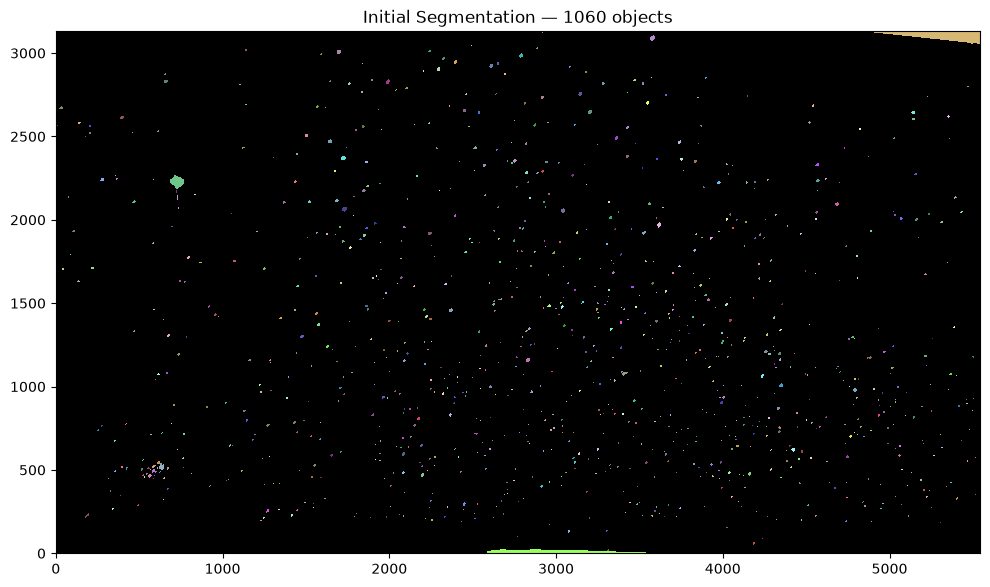

In [6]:
plt.figure(figsize=(10, 10))

plt.imshow(
    segmentation.data,
    origin="lower",
    cmap=segmentation.cmap,
    interpolation="nearest",
)

plt.title(
    f"Initial Segmentation — {segmentation.n_labels} objects"
)

plt.tight_layout()
plt.show()

In [7]:
# Separate overlapping detected objects

segmentation_deblended = deblend_sources(
    convolved,
    segmentation,
    npixels=MIN_PIXELS,
    nlevels=DEBLEND_LEVELS,
    contrast=DEBLEND_CONTRAST,
    progress_bar=True,
)

print("Before deblending:", segmentation.n_labels)
print("After deblending:", segmentation_deblended.n_labels)


Deblending:   0%|          | 0/844 [00:00<?, ?it/s]

Before deblending: 1060
After deblending: 1069


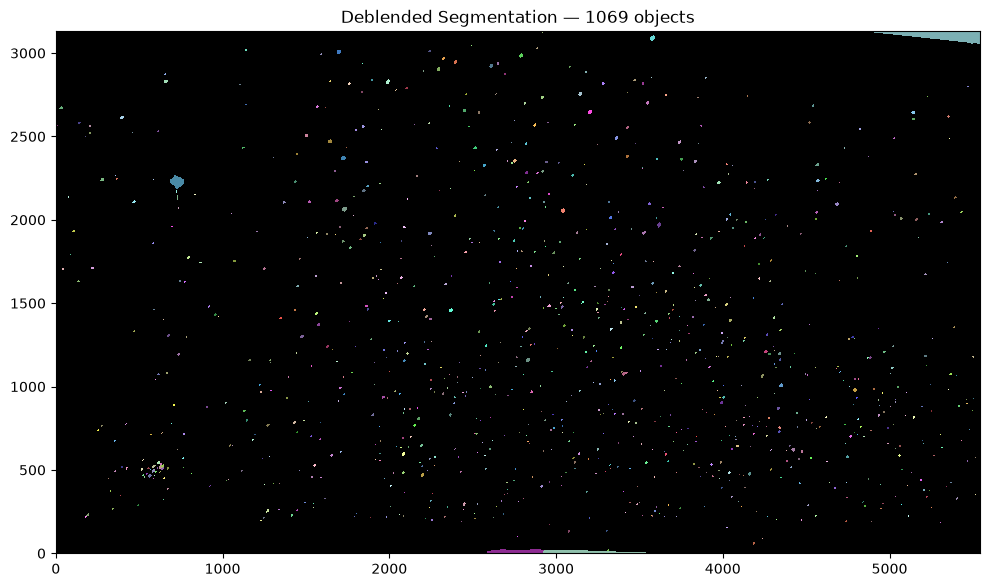

In [8]:
plt.figure(figsize=(10, 10))

plt.imshow(
    segmentation_deblended.data,
    origin="lower",
    cmap=segmentation_deblended.cmap,
    interpolation="nearest",
)

plt.title(
    f"Deblended Segmentation — "
    f"{segmentation_deblended.n_labels} objects"
)

plt.tight_layout()
plt.show()

In [9]:
background.background_rms
# Use the local background RMS as an approximate noise map

error_estimate = background.background_rms


# Measure detected objects

catalog = SourceCatalog(
    data_sub,
    segmentation_deblended,
    error=error_estimate,
    convolved_data=convolved,
)


columns = [
    "label",
    "xcentroid",
    "ycentroid",
    "area",
    "segment_flux",
    "segment_fluxerr",
    "ellipticity",
    "elongation",
]

object_table = catalog.to_table(
    columns=columns
)


# Calculate an approximate signal-to-noise ratio

object_table["snr"] = (
    object_table["segment_flux"]
    / object_table["segment_fluxerr"]
)


print("Number of detected objects:", len(object_table))

object_table[:10]

Number of detected objects: 1069


label,x_centroid,y_centroid,area,segment_flux,segment_flux_err,ellipticity,elongation,snr
,,,pix2,,,,,
int32,float64,float64,float64,float64,float64,float64,float64,float64
1,3312.4439691858697,19.480871642065456,76.0,21.632481687576668,0.07008564562086146,0.1571079761713785,1.1863915800955807,308.65780711503663
2,4185.3161646554245,58.59601803515061,142.0,40.675256246361165,0.08881250105945218,0.20445753863097915,1.2570039294686237,457.9902126518501
3,4239.469861152607,90.86597448161027,50.0,5.732665264379593,0.05315207325056441,0.197749184893945,1.246492968496147,107.85402927474176
4,2769.633715078678,100.97987327232197,45.0,16.075651099433646,0.1117887194375927,0.15871322434265545,1.1886553181804669,143.80387556374197
5,3077.5740622409553,131.07114435049942,152.0,38.76363590957361,0.09999286094863775,0.322068085013993,1.4750743812092704,387.66403463028126
6,3304.7681666428225,135.249319090576,60.0,7.887762490503252,0.060664851334573014,0.33576635214799466,1.5054943440968307,130.02195368453826
7,4025.4172770519804,154.17880883673772,60.0,7.7819314157242045,0.06018565293360179,0.2703692222205797,1.3705562189186007,129.2987786359884
8,5008.257779958811,164.10998206739382,28.0,2.370634611844434,0.03094128300723297,0.3057086222058062,1.4403174689811953,76.6172046353173


In [10]:
# Rename PNG-specific measurement columns

object_table.rename_column(
    "segment_flux",
    "integrated_intensity",
)

object_table.rename_column(
    "segment_fluxerr",
    "intensity_uncertainty",
)

object_table.rename_column(
    "snr",
    "snr_approx",
)


CATALOG_FILE = RESULTS_DIR / "png_object_catalog.csv"

object_table.write(
    CATALOG_FILE,
    format="ascii.csv",
    overwrite=True,
)

print("Objects:", len(object_table))
print("Catalog:", CATALOG_FILE)

Objects: 1069
Catalog: d:\AST\01_JWST_Image_Processing\notebooks\results\png_object_catalog.csv


In [11]:
# This PNG experiment exports only png_object_catalog.csv in the previous cell.

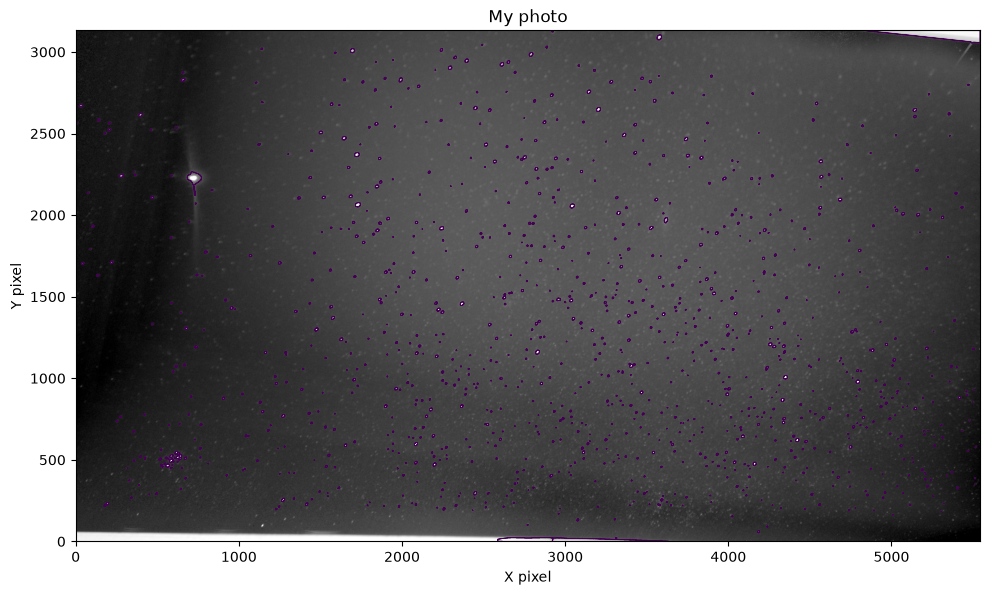

In [12]:
# Create source boundaries from the segmentation map

seg = segmentation_deblended.data

boundary = (
    (seg != np.roll(seg, 1, axis=0)) |
    (seg != np.roll(seg, -1, axis=0)) |
    (seg != np.roll(seg, 1, axis=1)) |
    (seg != np.roll(seg, -1, axis=1))
)

boundary &= seg > 0


# Display source boundaries

norm = ImageNormalize(
    image,
    interval=PercentileInterval(99.5),
    stretch=AsinhStretch(),
)

plt.figure(figsize=(10, 10))

plt.imshow(
    image,
    origin="lower",
    cmap="gray",
    norm=norm,
)

plt.contour(
    boundary,
    levels=[0.5],
    linewidths=0.6,
)

plt.xlabel("X pixel")
plt.ylabel("Y pixel")
plt.title("My photo")

plt.tight_layout()
plt.show()